In [1]:
#!pip install --upgrade transformers datasets scikit-learn


In [2]:
#import sys
#print(sys.executable)

In [3]:
#!{sys.executable} -m pip install --upgrade transformers

In [4]:
from transformers import TrainingArguments
print(TrainingArguments.__doc__)  # Should show evaluation_strategy and save_strategy



    TrainingArguments is the subset of the arguments we use in our example scripts **which relate to the training loop
    itself**.

    Using [`HfArgumentParser`] we can turn this class into
    [argparse](https://docs.python.org/3/library/argparse#module-argparse) arguments that can be specified on the
    command line.

    Parameters:
        output_dir (`str`, *optional*, defaults to `"trainer_output"`):
            The output directory where the model predictions and checkpoints will be written.
        do_train (`bool`, *optional*, defaults to `False`):
            Whether to run training or not. This argument is not directly used by [`Trainer`], it's intended to be used
            by your training/evaluation scripts instead. See the [example
            scripts](https://github.com/huggingface/transformers/tree/main/examples) for more details.
        do_eval (`bool`, *optional*):
            Whether to run evaluation on the validation set or not. Will be set to `True` if `ev

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [7]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Sarcasm Detection/Sarcasm_combined.csv')
df.head()


,tweet_id,text,label
0,866871160725794816,Triple Talaq par Burbak Kuchh nahi bolega,NO
1,880356789358743553,Batao ye uss site pr se akki sir ke verdict ni...,YES
2,877751493889105920,Hindu baheno par julam bardas nahi hoga @Tripl...,NO
3,901806457871466496,Naa bhai.. aisa nhi hai.. mere handle karne se...,NO
4,866264330748219392,#RememberingRajiv aaj agar musalman auraten tr...,NO


In [8]:
# Inspect columns
print(df.columns)

# Example: if columns are ['text', 'label'], adjust below accordingly
text_column = 'text'    # replace if different
label_column = 'label'  # replace if different

Index(['tweet_id', 'text', 'label'], dtype='object')


In [9]:
def clean_text(text):
    # Remove unwanted characters, keep letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", "", str(text))
    return text.lower()

df['clean_text'] = df[text_column].apply(clean_text)


In [10]:
# Encode labels as integers
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df[label_column])

# Split train/test
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['clean_text'], df['label_encoded'], test_size=0.2, random_state=42, stratify=df['label_encoded']
)


In [11]:
model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenization
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)

# Convert to Hugging Face Dataset
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': list(train_labels)
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': list(test_labels)
})


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(le.classes_))


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
training_args = TrainingArguments(
    output_dir="./bert_sarcasm",
    num_train_epochs=10,          # Allow more epochs; early stopping will halt training
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",    # Save checkpoint with best F1 score
    greater_is_better=True,        # Higher F1 is better
    save_total_limit=2,            # Keep only the 2 best checkpoints
    report_to="none",
)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall': recall_score(labels, preds, zero_division=0),
        'f1': f1_score(labels, preds, average='binary')
    }


In [15]:
from transformers import Trainer, EarlyStoppingCallback

early_stopping = EarlyStoppingCallback(
    early_stopping_patience=3,     # Stop if F1 doesn't improve for 3 epochs
    early_stopping_threshold=0.001 # Minimum improvement to count as better
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)


In [16]:
# Step 11: Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.174561,0.108169,0.960000,0.736000,0.910891,0.814159
2,0.129119,0.117579,0.954286,0.696296,0.930693,0.796610
3,0.119930,0.114945,0.960000,0.792079,0.792079,0.792079
4,0.107263,0.113210,0.966667,0.789474,0.891089,0.837209
5,0.085487,0.129184,0.963810,0.794393,0.841584,0.817308
6,0.057207,0.161179,0.961905,0.790476,0.821782,0.805825
7,0.039998,0.174718,0.963810,0.778761,0.871287,0.822430


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1841, training_loss=0.10193783948111962, metrics={'train_runtime': 555.1981, 'train_samples_per_second': 75.649, 'train_steps_per_second': 4.737, 'total_flos': 936716468184000.0, 'train_loss': 0.10193783948111962, 'epoch': 7.0})

In [17]:
# Step 12: Evaluate
trainer.evaluate()

{'eval_loss': 0.11331124603748322,
 'eval_accuracy': 0.9666666666666667,
 'eval_precision': 0.7894736842105263,
 'eval_recall': 0.8910891089108911,
 'eval_f1': 0.8372093023255814,
 'eval_runtime': 3.6731,
 'eval_samples_per_second': 285.863,
 'eval_steps_per_second': 8.984,
 'epoch': 7.0}

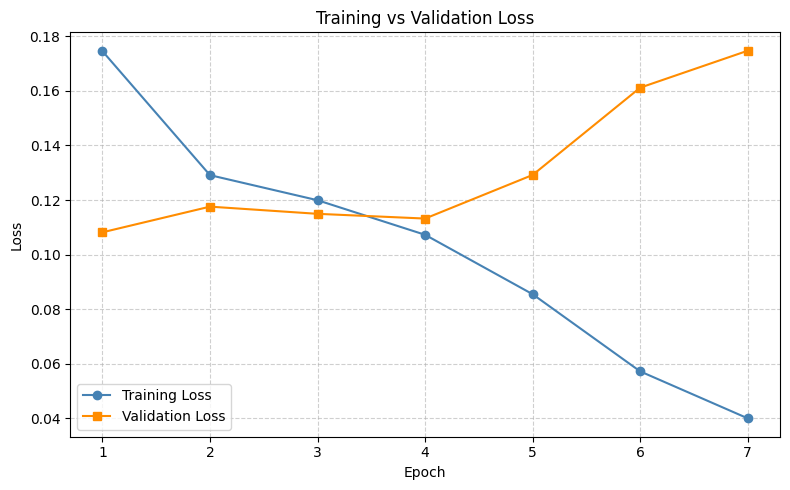

Loss curve saved to loss_curve.png


In [18]:
# ── Plot Training vs Validation Loss ──────────────────────────────────────
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_losses, val_losses, epochs_logged = [], [], []

for entry in log_history:
    if 'loss' in entry and 'eval_loss' not in entry:  # training loss entries
        train_losses.append(entry['loss'])
    if 'eval_loss' in entry:
        val_losses.append(entry['eval_loss'])
        epochs_logged.append(entry['epoch'])

# Align train/val losses (both logged per epoch)
min_len = min(len(train_losses), len(val_losses))
train_losses = train_losses[:min_len]
val_losses   = val_losses[:min_len]
epochs       = epochs_logged[:min_len]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', label='Training Loss',   color='steelblue')
plt.plot(epochs, val_losses,   marker='s', label='Validation Loss', color='darkorange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print('Loss curve saved to loss_curve.png')


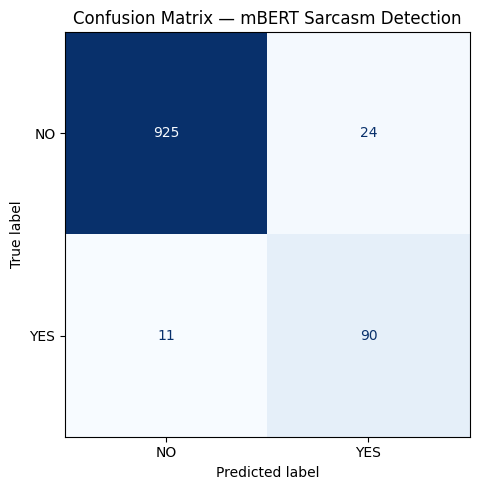

Confusion matrix saved to confusion_matrix.png


In [19]:
# ── Plot Confusion Matrix ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions on the test set
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Use original label names if available
class_names = le.classes_.astype(str).tolist()

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — mBERT Sarcasm Detection')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved to confusion_matrix.png')
